# Rootzone Soft-Sensor V4 — XGBoost + Pre-t0 History Features
## pH: 22 window + 9 history features | EC: 14 window + 9 history features
## History window: 24h before t0 | Redundant features removed via cross-correlation analysis

In [61]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# ==========================================
# 1. Data Loading & Helper Functions
# ==========================================
df = pd.read_csv('master.csv', parse_dates=['timestamp'])
df = df.sort_values('timestamp').set_index('timestamp')
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors='coerce')
master_df = df.copy().sort_index()

n_ph = int(master_df['ph'].notna().sum()) if 'ph' in master_df.columns else 0
n_ec = int(master_df['ec_ms'].notna().sum()) if 'ec_ms' in master_df.columns else 0
n_both = int((master_df['ph'].notna() & master_df['ec_ms'].notna()).sum()) if {'ph','ec_ms'}.issubset(master_df.columns) else 0

print(f'Loaded: {len(df)} rows')
print(f'Labeled samples -> pH: {n_ph}, EC: {n_ec}, both: {n_both}')

ACID_FERTS = ['Phosphoric acid[mg]-H3PO4']
SALT_FERTS = ['Monopotassium Phosphate[mg] -KH2PO4', 'Potassium Chloride[mg] - KCL',
              'Kortin [mg]', 'Ammonium Nitrate [mg] -NH4NO3', 'Gypsum - CaSO4*2H2O [mg]']

def _to_num(s, d=0.0): return pd.to_numeric(s, errors='coerce').fillna(d)

def _sum_avail(fr, cols):
    u = [c for c in cols if c in fr.columns]
    return float(fr[u].apply(pd.to_numeric, errors='coerce').fillna(0).sum().sum()) if u else 0.0

def _sum_avail_series(fr, cols):
    u = [c for c in cols if c in fr.columns]
    return fr[u].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1) if u else pd.Series(0.0, index=fr.index)

def _get_fert_any(fr):
    if 'fertilization_flag' in fr.columns: return _to_num(fr['fertilization_flag'])
    a = 'fertilization_type_a_flag' in fr.columns
    b = 'fertilization_type_b_flag' in fr.columns
    if a or b:
        fa = _to_num(fr['fertilization_type_a_flag']) if a else pd.Series(0., index=fr.index)
        fb = _to_num(fr['fertilization_type_b_flag']) if b else pd.Series(0., index=fr.index)
        return ((fa > 0) | (fb > 0)).astype(float)
    return pd.Series(0., index=fr.index)


Loaded: 16682 rows
Labeled samples -> pH: 109, EC: 109, both: 109


In [62]:
# ==========================================
# 2. Feature Extraction (Hybrid V3)
# pH: weighted recency dynamics (V2)
# EC: robust absolute drivers (V1)
# ==========================================
def get_features_for_row(master_df, anchor_idx, current_idx):
    t0 = pd.Timestamp(anchor_idx)
    t1 = pd.Timestamp(current_idx)
    ph0 = float(master_df.loc[t0, 'ph'])
    ec0 = float(master_df.loc[t0, 'ec_ms'])
    gap_h = float((t1 - t0).total_seconds() / 3600.0)
    safe_gap_h = max(gap_h, 0.16)

    # Strictly use [t0, t1) to avoid peeking at sample-time events
    seg = master_df.loc[(master_df.index >= t0) & (master_df.index < t1)]

    # Absolute sums
    fert_acid_total = _sum_avail(seg, ACID_FERTS)
    fert_salt_total = _sum_avail(seg, SALT_FERTS)
    fert_total = fert_acid_total + fert_salt_total
    irr_total = float(_to_num(seg['irrigation_ml_current']).sum()) if 'irrigation_ml_current' in seg.columns else 0.0

    # Time-weighted sums (recency-aware)
    fert_acid_s = _sum_avail_series(seg, ACID_FERTS)
    fert_salt_s = _sum_avail_series(seg, SALT_FERTS)
    fert_total_s = fert_acid_s + fert_salt_s
    irr_s = _to_num(seg['irrigation_ml_current']) if 'irrigation_ml_current' in seg.columns else pd.Series(0.0, index=seg.index)

    time_to_t1_hours = (t1 - seg.index).total_seconds() / 3600.0 if len(seg) else np.array([])
    decay_lambda = 0.34
    weights = np.exp(-decay_lambda * time_to_t1_hours) if len(seg) else np.array([])

    weighted_irr = float((irr_s * weights).sum()) if len(seg) else 0.0
    weighted_fert_acid = float((fert_acid_s * weights).sum()) if len(seg) else 0.0
    weighted_fert_salt = float((fert_salt_s * weights).sum()) if len(seg) else 0.0
    weighted_total_fert = float((fert_total_s * weights).sum()) if len(seg) else 0.0

    # Core drivers
    # fert_conc: +1 denominator keeps values stable when irr_total==0
    fert_conc = float(fert_total / (irr_total + 1.0))
    # fert_concentration used to divide by (irr_total + 1e-6), producing values
    # up to ~1e6 when irr_total==0 — extreme outliers that dominated tree splits.
    # Unified to the same +1 denominator as fert_conc, clipped as a safety net.
    fert_concentration = float(np.clip(fert_total / (irr_total + 1.0), 0, 1e4))
    salt_balance = float(fert_salt_total - irr_total)

    ET0_sum = float(_to_num(seg['ET0']).sum()) if 'ET0' in seg.columns else 0.0
    ET0_per_hour = float(ET0_sum / safe_gap_h)
    # leaching_fraction: clipped to [0, 100] — short gaps with near-zero ET0
    # produced astronomically large values that dominated tree splits.
    leaching_fraction = float(np.clip(irr_total / (ET0_sum + 1e-3), 0, 100))

    log_ec_drive = float(np.log(fert_conc + 0.01) - np.log(ec0 + 0.01))
    ph_drive = float(fert_total / (ph0 + 1e-3))

    # pH-specific features
    # h3po4_total: direct phosphoric acid dose in window
    H3PO4_COL = 'Phosphoric acid[mg]-H3PO4'
    h3po4_total = float(_to_num(seg[H3PO4_COL]).sum()) if H3PO4_COL in seg.columns else 0.0
    # acid_rate: phosphoric acid applied per hour — separates a large dose
    # over a long gap from a concentrated burst, which matters for pH drop.
    acid_rate = float(fert_acid_total / safe_gap_h)
    # ph_buffer_ratio: acid load relative to ionic strength (ec0). Higher EC
    # means more ions in solution = more buffering = same acid moves pH less.
    ph_buffer_ratio = float(fert_acid_total / (ec0 + 0.1))
    # soil_temp_sq: respiration rate roughly doubles per 10°C (Q10 rule),
    # so a quadratic term captures the nonlinear CO2 production effect on pH.
    soil_temp_sq = float(_to_num(seg['soil_temp_pred']).mean() ** 2) if 'soil_temp_pred' in seg.columns and len(seg) > 0 else 0.0

    # Climate dynamics
    if 'internal_air_temp_c' in seg.columns and 'internal_rh_%' in seg.columns and len(seg) > 0:
        ts = _to_num(seg['internal_air_temp_c'])
        rhs = _to_num(seg['internal_rh_%'])
        ess = 0.6108 * np.exp((17.27 * ts) / (ts + 237.3))
        vpds = ess * (1. - rhs / 100.)
        vpd_mean = float(vpds.mean())
    else:
        vpd_mean = 0.0

    soil_temp_mean = float(_to_num(seg['soil_temp_pred']).mean()) if 'soil_temp_pred' in seg.columns and len(seg) > 0 else 0.0
    canopy = float(_to_num(seg['canopy_cover']).mean()) if 'canopy_cover' in seg.columns and len(seg) > 0 else 0.0
    transpiration_pull = float(vpd_mean * canopy)
    evapo_concentration = float(ET0_sum * canopy)

    temp_s = _to_num(seg['internal_air_temp_c']) if 'internal_air_temp_c' in seg.columns else pd.Series(dtype=float)
    if len(temp_s) > 1:
        temp_trend = float(temp_s.iloc[-1] - temp_s.iloc[0])
        temp_range = float(temp_s.max() - temp_s.min())
    else:
        temp_trend = 0.0
        temp_range = 0.0

    rad_s = _to_num(seg['internal_radiation']) if 'internal_radiation' in seg.columns else pd.Series(dtype=float)
    rad_max = float(rad_s.max()) if len(rad_s) > 0 else 0.0
    daylight_proportion = float((rad_s > 10).sum() / 6.0 / safe_gap_h) if len(rad_s) > 0 else 0.0

    # Interaction features (batch 1) — placed here so vpd_mean, soil_temp_mean,
    # and rad_s are all already defined.
    # rad_integral: cumulative light energy (Wh/m²) — plants integrate radiation
    # over the full window, not just whether it was daytime.
    rad_integral = float(rad_s.sum() * (10.0 / 60.0)) if len(rad_s) > 0 else 0.0
    # ph_deviation: distance from agronomic optimum (6.5) — encodes the
    # operator mean-reversion pressure that ph0 alone cannot capture.
    ph_deviation = float(ph0 - 6.5)
    # photo_temp_interaction: vpd_mean × soil_temp_mean — coupled biochemical
    # CO2 uptake rate; neither driver predicts pH change independently.
    photo_temp_interaction = float(vpd_mean * soil_temp_mean)

    # Hours since events
    if 'irrigation_ml_current' in seg.columns and len(seg) > 0:
        ie = _to_num(seg['irrigation_ml_current'])
        ii = ie[ie > 0].index
        hrs_since_irr = float((t1 - ii.max()).total_seconds() / 3600.) if len(ii) > 0 else gap_h
    else:
        hrs_since_irr = gap_h

    fser = _get_fert_any(seg) if len(seg) > 0 else pd.Series(dtype=float)
    fi2 = fser[fser > 0].index
    hrs_since_fert = float((t1 - fi2.max()).total_seconds() / 3600.) if len(fi2) > 0 else gap_h

    # Interaction features (batch 2) — placed here so hrs_since_irr is defined.
    # acid_dilution: acid / (irr + fert + 1) — actual acid concentration in
    # the liquid applied; neither term alone captures dilution by irrigation.
    acid_dilution = float(fert_acid_total / (irr_total + fert_total + 1.0))
    # canopy_et0: canopy × ET0_sum — actual photosynthetic demand met by crop;
    # small canopy at high ET0 has minimal CO2 uptake and pH effect.
    canopy_et0 = float(canopy * ET0_sum)
    # salt_stress_index: hrs_since_irr × ec0 — salt concentration builds up
    # when irrigation is withheld; high EC × long gap = stronger buffering.
    salt_stress_index = float(hrs_since_irr * ec0)

    # Interaction features (batch 3)
    # rad_x_canopy: mean radiation x canopy = actual light intercepted by leaves,
    # the direct driver of photosynthesis and CO2 uptake (r=0.51 with dph).
    rad_x_canopy = float(rad_s.mean() * canopy) if len(rad_s) > 0 else 0.0
    # temp_x_canopy: soil_temp x canopy = root mass x temperature drives root
    # respiration CO2 production which acidifies the rootzone.
    temp_x_canopy = float(soil_temp_mean * canopy)

    # Time-of-day (diurnal cycles)
    hour_a = t0.hour + t0.minute / 60.0
    hour_b = t1.hour + t1.minute / 60.0

    return {
        'ph0': ph0,
        'ec0': ec0,
        'gap_hours': gap_h,

        # absolute totals
        'irr_total_t0_t1': irr_total,
        'fert_total_t0_t1': fert_total,
        'fert_salt_total_t0_t1': fert_salt_total,
        'salt_balance_t0_t1': salt_balance,
        'ET0_sum_t0_t1': ET0_sum,

        # weighted totals
        'weighted_irr': weighted_irr,
        'weighted_total_fert': weighted_total_fert,
        'weighted_fert_acid': weighted_fert_acid,
        'weighted_fert_salt': weighted_fert_salt,

        # driver terms
        'fert_conc': fert_conc,
        'fert_concentration': fert_concentration,
        'log_ec_drive': log_ec_drive,
        'ph_drive': ph_drive,
        'leaching_fraction': leaching_fraction,
        'ET0_per_hour': ET0_per_hour,

        # pH-specific
        'acid_rate': acid_rate,
        'ph_buffer_ratio': ph_buffer_ratio,
        'soil_temp_sq': soil_temp_sq,

        # interaction features (batch 1)
        'rad_integral': rad_integral,
        'ph_deviation': ph_deviation,
        'photo_temp_interaction': photo_temp_interaction,

        # interaction features (batch 2)
        'acid_dilution': acid_dilution,
        'canopy_et0': canopy_et0,
        'salt_stress_index': salt_stress_index,

        # interaction features (batch 3)
        'rad_x_canopy': rad_x_canopy,
        'temp_x_canopy': temp_x_canopy,

        # climate
        'vpd_mean': vpd_mean,
        'soil_temp_mean': soil_temp_mean,
        'soil_temp_t0': soil_temp_mean,  # alias: soil temp at anchor point
        'canopy': canopy,
        'transpiration_pull': transpiration_pull,
        'evapo_concentration': evapo_concentration,

        # fertilization chemistry
        'h3po4_total': h3po4_total,
        # recency / dynamics
        'hrs_since_irr': hrs_since_irr,
        'hrs_since_fert': hrs_since_fert,
        'temp_trend': temp_trend,
        'temp_range': temp_range,
        'rad_max': rad_max,
        'daylight_proportion': daylight_proportion,

        # diurnal
        'hour_sin_a': float(np.sin(2 * np.pi * hour_a / 24)),
        'hour_cos_a': float(np.cos(2 * np.pi * hour_a / 24)),
        'hour_sin_b': float(np.sin(2 * np.pi * hour_b / 24)),
        'hour_cos_b': float(np.cos(2 * np.pi * hour_b / 24)),
    }


# ==========================================
# 2b. History Feature Extraction (24h before t0)
# 9 features selected by cross-correlation analysis:
#   Dropped H_ET0_sum     — r=0.836 with W_temp_x_canopy (redundant)
#   Dropped H_rad_integral — r=0.793 with W_temp_x_canopy (redundant)
#   Dropped H_vpd_mean    — r=0.791 with H_temp_mean (internal redundancy)
#   Dropped H_salt_total  — r=0.976 with H_acid_total (internal redundancy)
#   Dropped H_ec_mean     — r~1.0 with ec0 anchor
#   Dropped H_ph_range, H_ph_mean, H_ph_slope, H_fert_events, H_irr_events,
#           H_ec_slope, H_nh4_total, H_acid_rate
#   Kept H_temp_slope (r=−0.511 with ΔpH — strongest single correlation found)
# ==========================================
def get_history_features(master_df, t0, t1):
    """
    Extract 7 history features anchored to t1.

    All irr/fert windows use [t1-Xh, t1) — the full 24h leading up to
    the measurement, including the t0→t1 prediction window itself.
    No leakage: only environmental sensor values are read, not pH/EC at t1.

    Irrigation sub-windows (anchored to t1):
      recent : [t1-6h,  t1)   — immediate dilution effect
      mid    : [t1-12h, t1-6h) — nitrification peak (8-16h lag)
      prior  : [t1-24h, t1-12h) — residual buffering / background

    Acid fertilization:
      hist_acid_decay — exponentially decayed sum over [t1-24h, t1)
      decay from t1: dose * exp(-λ * hrs_before_t1), λ=0.34/hr
      encodes both amount and recency in one feature.

    State features (anchored to t0, full 24h before t0):
      hist_salt_buildup   — net salt accumulation entering the window
      hist_hrs_since_fert — hours since last fertigation before t0
      hist_hrs_since_irr  — hours since last irrigation before t0
    """
    t0 = pd.Timestamp(t0)
    t1 = pd.Timestamp(t1)

    w_prior_start = t1 - pd.Timedelta(hours=24)

    def _get_seg(start, stop):
        """Rows in [start, stop)."""
        if start >= stop:
            return master_df.iloc[0:0]
        return master_df.loc[(master_df.index >= start) & (master_df.index < stop)]

    # ── Irrigation sub-windows: full [t1-Xh, t1) including t0→t1 ────────────
    seg_irr_recent = _get_seg(t1 - pd.Timedelta(hours=6),  t1)
    seg_irr_mid    = _get_seg(t1 - pd.Timedelta(hours=12), t1 - pd.Timedelta(hours=6))
    seg_irr_prior  = _get_seg(t1 - pd.Timedelta(hours=24), t1 - pd.Timedelta(hours=12))

    def _irr(seg):
        if 'irrigation_ml_current' not in seg.columns or len(seg) == 0:
            return 0.0
        return float(_to_num(seg['irrigation_ml_current']).sum())

    irr_recent = _irr(seg_irr_recent)
    irr_mid    = _irr(seg_irr_mid)
    irr_prior  = _irr(seg_irr_prior)

    # ── Salt ramp: full [t1-24h, t1) anchored to t1 ──────────────────────────
    # hist_salt_ramp = sum(dose_i * (1 - exp(-λ * hrs_before_t1)))
    # Salts accumulate and equilibrate — opposite of acid decay.
    # Recent dose (1h ago) gets low weight (not dissolved yet).
    # Old dose (20h ago) gets weight ~1.0 (fully equilibrated).
    seg_salt_full = _get_seg(w_prior_start, t1)
    DECAY_LAMBDA  = 0.34
    hist_salt_ramp = 0.0
    if len(seg_salt_full) > 0:
        salt_doses = _sum_avail_series(seg_salt_full, SALT_FERTS)
        nonzero_salt = salt_doses > 0
        if nonzero_salt.any():
            hrs_s = np.array((t1 - seg_salt_full.index[nonzero_salt]).total_seconds()) / 3600.0
            hist_salt_ramp = float((salt_doses[nonzero_salt].values *
                                    (1.0 - np.exp(-DECAY_LAMBDA * hrs_s))).sum())

    # ── Acid decay: full [t1-24h, t1) anchored to t1 ─────────────────────────
    # hist_acid_decay = sum(dose_i * exp(-λ * hrs_before_t1))
    # Events near t1 get high weight; events 24h before t1 get low weight.
    # λ=0.34/hr matches V3 recency decay constant.
    # Vectorized — avoids O(n²) slowdown during walk-forward retraining.
    seg_acid_full = _get_seg(w_prior_start, t1)
    DECAY_LAMBDA  = 0.34
    if len(seg_acid_full) > 0:
        acid_doses = _sum_avail_series(seg_acid_full, ACID_FERTS)
        nonzero_mask = acid_doses > 0
        if nonzero_mask.any():
            hrs_before_t1 = np.array((t1 - seg_acid_full.index[nonzero_mask]).total_seconds()) / 3600.0
            hist_acid_decay = float((acid_doses[nonzero_mask].values *
                                     np.exp(-DECAY_LAMBDA * hrs_before_t1)).sum())
        else:
            hist_acid_decay = 0.0
    else:
        hist_acid_decay = 0.0

    # ── State features: full 24h before t0 ──────────────────────────────────
    seg_state = _get_seg(t0 - pd.Timedelta(hours=24), t0)

    if len(seg_state) > 1:
        hirr_s     = _to_num(seg_state['irrigation_ml_current']) if 'irrigation_ml_current' in seg_state.columns else pd.Series(0.0, index=seg_state.index)
        irr_s_sum  = float(hirr_s.sum())
        h_salt     = _sum_avail(seg_state, SALT_FERTS)
        hist_salt_buildup = float(h_salt - irr_s_sum * 0.1)

        hfert      = _get_fert_any(seg_state)
        fert_times = seg_state.index[hfert > 0]
        hist_hrs_since_fert = float((t0 - fert_times[-1]).total_seconds() / 3600.) if len(fert_times) > 0 else 24.0

        hirr_times = seg_state.index[hirr_s > 0]
        hist_hrs_since_irr = float((t0 - hirr_times[-1]).total_seconds() / 3600.) if len(hirr_times) > 0 else 24.0
    else:
        hist_salt_buildup   = 0.0
        hist_hrs_since_fert = 24.0
        hist_hrs_since_irr  = 24.0

    return {
        # irrigation sub-windows anchored to t1 (full window including t0→t1)
        'hist_irr_recent':     irr_recent,
        'hist_irr_mid':        irr_mid,
        'hist_irr_prior':      irr_prior,
        # salt ramp anchored to t1 (equilibration weighting, λ=0.34/hr)
        'hist_salt_ramp':      hist_salt_ramp,
        # acid decay anchored to t1 (amount × recency, λ=0.34/hr)
        'hist_acid_decay':     hist_acid_decay,
        # state features anchored to t0 (24h before window start)
        'hist_salt_buildup':   hist_salt_buildup,
        'hist_hrs_since_fert': hist_hrs_since_fert,
        'hist_hrs_since_irr':  hist_hrs_since_irr,
    }


def get_features_v4(master_df, anchor_idx, current_idx):
    """Combine window features (V3) + history features (V4).
    Passes both t0 (anchor_idx) and t1 (current_idx) to history extractor
    so sub-windows are anchored to t1 as designed.
    """
    window = get_features_for_row(master_df, anchor_idx, current_idx)
    history = get_history_features(master_df, t0=anchor_idx, t1=current_idx)
    return {**window, **history}


In [63]:
# ==========================================
# 3. Feature Lists + Hyperparameters (V4)
# ==========================================
# V4 adds 10 history features to both models.
# Design principles:
#   - Climate features: window only (t0→t1). Plants reset each light/dark cycle.
#   - Irrigation & fertilization: 3 sub-windows anchored to t1, rows before t0 only.
#     This captures the full biological lag (nitrification 8-16h, buffering 12-24h)
#     without overlapping the prediction window.
#   - State features: 4 features summarising background conditions before t0.

HIST_FEATS = [
    # Windowed irrigation — 3 sub-windows before t0, anchored to t1
    'hist_irr_recent',     # Irrigation 0–6h before t1 (immediate dilution effect)
    'hist_irr_mid',        # Irrigation 6–12h before t1 (nitrification peak window)
    'hist_irr_prior',      # Irrigation 12–24h before t1 (background/prior cycle)
    # Fertilization — exponential decay encoding amount + recency in one feature
    'hist_acid_decay',     # sum(acid_dose * exp(-0.34 * hrs_ago)) over 24h before t0
    # State features — full 24h before t0 (background conditions)
    'hist_salt_buildup',   # Net salt accumulation entering the window
    'hist_hrs_since_fert', # Hours since last fertigation before t0
    'hist_hrs_since_irr',  # Hours since last irrigation before t0
]

# pH: 8 window + 7 history = 15 features
# Climate trimmed from 11 → 5 features:
#   Kept (highest importance): photo_temp_interaction, ET0_per_hour,
#     temp_x_canopy, rad_integral, transpiration_pull
#   Dropped (absorbed by interactions or low importance):
#     canopy, temp_trend, temp_range, rad_max, canopy_et0, rad_x_canopy
feature_cols_ph = [
    'ph0', 'ec0',
    'gap_hours',
    # climate — 5 features (trimmed from 11)
    'ET0_per_hour',
    'transpiration_pull',
    'photo_temp_interaction',
    'rad_integral',
    'temp_x_canopy',
    # history features (pre-t0, anchored to t1)
    *HIST_FEATS,
]

# EC: 8 window + 7 history = 15 features
# Removed window irr/fert features replaced by history sub-windows:
#   irr_total_t0_t1, salt_balance_t0_t1, fert_conc,
#   hrs_since_irr, hrs_since_fert, leaching_fraction
# ET0: keep ET0_sum_t0_t1 only (cumulative evaporation drives salt concentration)
feature_cols_ec = [
    'ec0', 'ph0',
    'gap_hours',
    'ET0_sum_t0_t1', 'evapo_concentration',
    'transpiration_pull',
    'log_ec_drive',
    'temp_trend',
    'soil_temp_mean',
    # history features (pre-t0, anchored to t1)
    *HIST_FEATS,
]


# pH hyperparams — re-tuned for 31-feature set
# Stronger regularization vs V3: colsample_bytree 0.6→0.5, reg_alpha 2.0→3.0
# to handle 9 additional features without overfitting on 109 labeled points.
best_ph_params = {
    'n_estimators': 800,
    'learning_rate': 0.06,
    'max_depth': 4,
    'min_child_weight': 3,
    'subsample': 0.6,
    'colsample_bytree': 0.5,
    'reg_alpha': 3.0,
    'reg_lambda': 1.0,
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': 'hist'
}

# EC hyperparams — re-tuned for 23-feature set
# Slightly stronger regularization vs V3 baseline.
best_ec_params = {
    'n_estimators': 100,
    'learning_rate': 0.05,
    'max_depth': 2,
    'min_child_weight': 10,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'reg_alpha': 0.5,
    'reg_lambda': 1.5,
    'random_state': 42,
    'n_jobs': -1,
    'objective': 'reg:pseudohubererror',
    'huber_slope': 0.1,
}

print(f"pH features: {len(feature_cols_ph)} ({len(feature_cols_ph)-len(HIST_FEATS)} window + {len(HIST_FEATS)} history)")
print(f"EC features: {len(feature_cols_ec)} ({len(feature_cols_ec)-len(HIST_FEATS)} window + {len(HIST_FEATS)} history)")


pH features: 15 (8 window + 7 history)
EC features: 16 (9 window + 7 history)


In [64]:
# ==========================================
# 4. Walk-Forward Validation & Training
# ==========================================
def fit_models(tdf, ph_params=None, ec_params=None):
    y_ph = tdf['ph_true'] - tdf['ph0']
    y_ec = tdf['ec_true'] - tdf['ec0']

    pm = xgb.XGBRegressor(**(ph_params or {}))
    em = xgb.XGBRegressor(**(ec_params or {}))

    pm.fit(tdf[feature_cols_ph], y_ph, verbose=False)
    em.fit(tdf[feature_cols_ec], y_ec, verbose=False)
    return pm, em


def run_walkforward(master_df, sensor_idx, warmup, ph_params=None, ec_params=None, retrain_every_sample=True):
    train_rows = []
    for j in range(1, warmup + 1):
        f = get_features_v4(master_df, sensor_idx[j-1], sensor_idx[j])
        f['ph_true'] = float(master_df.loc[sensor_idx[j], 'ph'])
        f['ec_true'] = float(master_df.loc[sensor_idx[j], 'ec_ms'])
        f['timestamp'] = sensor_idx[j]
        train_rows.append(f)
    train_df = pd.DataFrame(train_rows).set_index('timestamp').sort_index()

    ph_model, ec_model = fit_models(train_df, ph_params, ec_params)

    anchor_idx = sensor_idx[warmup]
    results = []
    retrain_count = 0

    for cur in master_df.loc[anchor_idx:].index:
        feats = get_features_v4(master_df, anchor_idx, cur)

        if feats['gap_hours'] <= 0:
            dph, dec = 0.0, 0.0
        else:
            dph = float(ph_model.predict(pd.DataFrame([feats])[feature_cols_ph])[0])
            dec = float(ec_model.predict(pd.DataFrame([feats])[feature_cols_ec])[0])

        ph_pred = feats['ph0'] + dph
        ec_pred = max(0.0, feats['ec0'] + dec)

        row = {
            'timestamp': cur,
            'gap_hours': feats['gap_hours'],
            'ph0': feats['ph0'], 'ec0': feats['ec0'],
            'ph_pred': ph_pred, 'ec_pred': ec_pred,
            'has_actual': False,
            'ph_true': np.nan, 'ec_true': np.nan,
            'ph_naive': np.nan, 'ec_naive': np.nan,
            'ph_abs_error': np.nan, 'ec_abs_error': np.nan,
            'ph_abs_error_naive': np.nan, 'ec_abs_error_naive': np.nan
        }

        has = pd.notna(master_df.loc[cur, 'ph']) and pd.notna(master_df.loc[cur, 'ec_ms'])
        if has:
            ph_true = float(master_df.loc[cur, 'ph'])
            ec_true = float(master_df.loc[cur, 'ec_ms'])

            row.update({
                'has_actual': True,
                'ph_true': ph_true, 'ec_true': ec_true,
                'ph_naive': feats['ph0'], 'ec_naive': feats['ec0'],
                'ph_abs_error': abs(ph_pred - ph_true),
                'ec_abs_error': abs(ec_pred - ec_true),
                'ph_abs_error_naive': abs(feats['ph0'] - ph_true),
                'ec_abs_error_naive': abs(feats['ec0'] - ec_true),
            })

            if retrain_every_sample and cur != anchor_idx:
                nr = {**feats, 'ph_true': ph_true, 'ec_true': ec_true, 'timestamp': cur}
                train_df = pd.concat([train_df, pd.DataFrame([nr]).set_index('timestamp')]).sort_index()
                ph_model, ec_model = fit_models(train_df, ph_params, ec_params)
                retrain_count += 1

            anchor_idx = cur

        results.append(row)

    res_df = pd.DataFrame(results).set_index('timestamp')
    ev = res_df[res_df['has_actual']].copy()

    def _rmse(y, yhat):
        return float(np.sqrt(mean_squared_error(y, yhat)))

    metrics = {
        'warmup': warmup,
        'n_test': int(len(ev)),
        'retrains': int(retrain_count),
        'ph_mae': float(mean_absolute_error(ev['ph_true'], ev['ph_pred'])) if len(ev) else np.nan,
        'ph_rmse': _rmse(ev['ph_true'], ev['ph_pred']) if len(ev) else np.nan,
        'ph_mae_naive': float(mean_absolute_error(ev['ph_true'], ev['ph_naive'])) if len(ev) else np.nan,
        'ec_mae': float(mean_absolute_error(ev['ec_true'], ev['ec_pred'])) if len(ev) else np.nan,
        'ec_rmse': _rmse(ev['ec_true'], ev['ec_pred']) if len(ev) else np.nan,
        'ec_mae_naive': float(mean_absolute_error(ev['ec_true'], ev['ec_naive'])) if len(ev) else np.nan,
        'ph_r2': float(r2_score(ev['ph_true'], ev['ph_pred'])) if len(ev) >= 2 else np.nan,
        'ec_r2': float(r2_score(ev['ec_true'], ev['ec_pred'])) if len(ev) >= 2 else np.nan,
    }

    return metrics, ev, res_df, ph_model, ec_model


def _build_skip_rows(master_df, sensor_idx, up_to_pos, max_gap_hours=48.0):
    """Build augmented training rows using skip intervals (skip-1 and skip-2).

    A skip interval (sensor_idx[i] -> sensor_idx[k], k > i+1) is added to
    training only after BOTH endpoints have been observed and tested — i.e.
    only when up_to_pos >= k. This guarantees zero leakage.

    max_gap_hours: skip intervals longer than this are excluded to avoid
    anchoring predictions on stale rootzone state (default 48h).
    """
    skip_rows = []
    for k in range(1, up_to_pos + 1):
        t1 = pd.Timestamp(sensor_idx[k])
        # skip-1: bridge over one intermediate point
        if k >= 2:
            t0 = pd.Timestamp(sensor_idx[k-2])
            gap_h = (t1 - t0).total_seconds() / 3600.0
            if gap_h <= max_gap_hours:
                f = get_features_v4(master_df, sensor_idx[k-2], sensor_idx[k])
                f['ph_true'] = float(master_df.loc[t1, 'ph'])
                f['ec_true'] = float(master_df.loc[t1, 'ec_ms'])
                f['timestamp'] = t1 + pd.Timedelta(microseconds=1)  # unique index
                skip_rows.append(f)
        # skip-2: bridge over two intermediate points
        if k >= 3:
            t0 = pd.Timestamp(sensor_idx[k-3])
            gap_h = (t1 - t0).total_seconds() / 3600.0
            if gap_h <= max_gap_hours:
                f = get_features_v4(master_df, sensor_idx[k-3], sensor_idx[k])
                f['ph_true'] = float(master_df.loc[t1, 'ph'])
                f['ec_true'] = float(master_df.loc[t1, 'ec_ms'])
                f['timestamp'] = t1 + pd.Timedelta(microseconds=2)  # unique index
                skip_rows.append(f)
    return skip_rows


def run_walkforward_single(master_df, sensor_idx, warmup, target,
                           model_params=None, retrain_every_sample=True,
                           skip_max_gap_hours=24.0):
    """Walk-forward for a single target ('ph' or 'ec').
    Allows each target to use its own optimal warmup independently.
    Augments training with skip intervals (skip-1 + skip-2, gap <= skip_max_gap_hours)
    after each observed label — zero leakage guaranteed.
    Skip augmentation is applied to pH only (EC stays consecutive to avoid noise).
    """
    assert target in ('ph', 'ec'), "target must be 'ph' or 'ec'"
    true_col   = 'ph'   if target == 'ph' else 'ec_ms'
    feat_cols  = feature_cols_ph if target == 'ph' else feature_cols_ec
    pred_key   = 'ph_pred'  if target == 'ph' else 'ec_pred'
    true_key   = 'ph_true'  if target == 'ph' else 'ec_true'
    naive_key  = 'ph_naive' if target == 'ph' else 'ec_naive'

    # Build warmup training set (consecutive intervals only)
    train_rows = []
    for j in range(1, warmup + 1):
        f = get_features_v4(master_df, sensor_idx[j-1], sensor_idx[j])
        f['ph_true'] = float(master_df.loc[sensor_idx[j], 'ph'])
        f['ec_true'] = float(master_df.loc[sensor_idx[j], 'ec_ms'])
        f['timestamp'] = sensor_idx[j]
        train_rows.append(f)

    # Add skip intervals for warmup period (pH only)
    if target == 'ph':
        skip_rows = _build_skip_rows(master_df, sensor_idx, warmup, skip_max_gap_hours)
        all_rows = train_rows + skip_rows
    else:
        all_rows = train_rows
    train_df = pd.DataFrame(all_rows).set_index('timestamp').sort_index()

    # Fit initial model for this target only
    def _fit(tdf):
        y = tdf[true_key] - tdf['ph0' if target == 'ph' else 'ec0']
        m = xgb.XGBRegressor(**(model_params or {}))
        m.fit(tdf[feat_cols], y, verbose=False)
        return m

    model = _fit(train_df)
    anchor_idx = sensor_idx[warmup]
    # track which sensor_idx position we're at for skip interval bookkeeping
    current_sensor_pos = warmup
    results = []
    retrain_count = 0

    for cur in master_df.loc[anchor_idx:].index:
        feats = get_features_v4(master_df, anchor_idx, cur)

        if feats['gap_hours'] <= 0:
            delta = 0.0
        else:
            delta = float(model.predict(pd.DataFrame([feats])[feat_cols])[0])

        anchor_val = feats['ph0'] if target == 'ph' else feats['ec0']
        pred = anchor_val + delta
        if target == 'ec':
            pred = max(0.0, pred)

        row = {
            'timestamp': cur,
            'gap_hours': feats['gap_hours'],
            pred_key: pred,
            'has_actual': False,
            true_key: np.nan,
            naive_key: np.nan,
        }

        has = pd.notna(master_df.loc[cur, true_col])
        if has:
            true_val = float(master_df.loc[cur, true_col])
            row.update({
                'has_actual': True,
                true_key: true_val,
                naive_key: anchor_val,
            })

            if retrain_every_sample and cur != anchor_idx:
                # Add consecutive interval
                nr = {**feats, 'ph_true': float(master_df.loc[cur, 'ph']),
                      'ec_true': float(master_df.loc[cur, 'ec_ms']), 'timestamp': cur}
                new_rows = [pd.DataFrame([nr]).set_index('timestamp')]

                # Add new skip intervals (pH only, zero leakage)
                current_sensor_pos += 1
                if target == 'ph':
                    new_skips = _build_skip_rows(
                        master_df, sensor_idx,
                        up_to_pos=current_sensor_pos,
                        max_gap_hours=skip_max_gap_hours
                    )
                    new_skips_at_cur = [
                        s for s in new_skips
                        if s['timestamp'] >= cur and s['timestamp'] <= cur + pd.Timedelta(microseconds=10)
                    ]
                    if new_skips_at_cur:
                        new_rows.append(
                            pd.DataFrame(new_skips_at_cur).set_index('timestamp')
                        )

                train_df = pd.concat(
                    [train_df] + new_rows
                ).sort_index()
                model = _fit(train_df)
                retrain_count += 1

            anchor_idx = cur

        results.append(row)

    res_df = pd.DataFrame(results).set_index('timestamp')
    ev = res_df[res_df['has_actual']].copy()

    def _rmse(y, yhat):
        return float(np.sqrt(mean_squared_error(y, yhat)))

    metrics = {
        'warmup': warmup,
        'target': target,
        'n_test': int(len(ev)),
        'retrains': int(retrain_count),
        f'{target}_mae':       float(mean_absolute_error(ev[true_key], ev[pred_key])) if len(ev) else np.nan,
        f'{target}_rmse':      _rmse(ev[true_key], ev[pred_key]) if len(ev) else np.nan,
        f'{target}_mae_naive': float(mean_absolute_error(ev[true_key], ev[naive_key])) if len(ev) else np.nan,
        f'{target}_r2':        float(r2_score(ev[true_key], ev[pred_key])) if len(ev) >= 2 else np.nan,
    }
    metrics[f'{target}_gain_mae'] = metrics[f'{target}_mae_naive'] - metrics[f'{target}_mae']

    return metrics, ev, res_df, model


In [65]:
# ==========================================
# 5. Training — Fixed Warmups (pH=50, EC=40) — V4 with history features
# ==========================================
sensor_idx = list(master_df.index[master_df['ph'].notna() & master_df['ec_ms'].notna()])
print(f'Joint labeled timestamps: {len(sensor_idx)}')

WARMUP_PH = 50
WARMUP_EC = 40

m_ph, ev_ph, res_ph, ph_model = run_walkforward_single(
    master_df, sensor_idx, warmup=WARMUP_PH, target='ph', model_params=best_ph_params)

m_ec, ev_ec, res_ec, ec_model = run_walkforward_single(
    master_df, sensor_idx, warmup=WARMUP_EC, target='ec', model_params=best_ec_params)

print(f'\npH  (warmup={WARMUP_PH}): MAE={m_ph["ph_mae"]:.4f}  naive={m_ph["ph_mae_naive"]:.4f}  gain={m_ph["ph_gain_mae"]:.4f}  R2={m_ph["ph_r2"]:.4f}')
print(f'EC  (warmup={WARMUP_EC}): MAE={m_ec["ec_mae"]:.4f}  naive={m_ec["ec_mae_naive"]:.4f}  gain={m_ec["ec_gain_mae"]:.4f}  R2={m_ec["ec_r2"]:.4f}')

Joint labeled timestamps: 109

pH  (warmup=50): MAE=0.3924  naive=0.9063  gain=0.5139  R2=0.8618
EC  (warmup=40): MAE=0.1798  naive=0.1814  gain=0.0016  R2=0.8175


In [66]:
# ==========================================
# 6. Gap-Bin Error Report
# ==========================================
def gap_bin_report_single(ev, target):
    pred_col  = f'{target}_pred'
    true_col  = f'{target}_true'
    naive_col = f'{target}_naive'
    ev = ev.copy()
    ev['gap_bin'] = pd.cut(ev['gap_hours'], [-np.inf, 12, 24, np.inf], labels=['0-12h', '12-24h', '24h+'])
    out = []
    for gb, g in ev.groupby('gap_bin', observed=False):
        if len(g) == 0:
            continue
        out.append({
            'gap_bin': str(gb),
            'n': len(g),
            f'{target}_mae':   round(g[pred_col].sub(g[true_col]).abs().mean(), 6),
            f'{target}_naive': round(g[naive_col].sub(g[true_col]).abs().mean(), 6),
        })
    return pd.DataFrame(out)

print(f'pH gap-bin report (warmup={WARMUP_PH})')
display(gap_bin_report_single(ev_ph, 'ph'))

print(f'\nEC gap-bin report (warmup={WARMUP_EC})')
display(gap_bin_report_single(ev_ec, 'ec'))


pH gap-bin report (warmup=50)


,gap_bin,n,ph_mae,ph_naive
0,0-12h,45,0.376659,0.714667
1,12-24h,11,0.507431,1.641818
2,24h+,3,0.206349,1.083333



EC gap-bin report (warmup=40)


,gap_bin,n,ec_mae,ec_naive
0,0-12h,50,0.201240,0.201120
1,12-24h,14,0.112175,0.112443
2,24h+,5,0.154505,0.176764


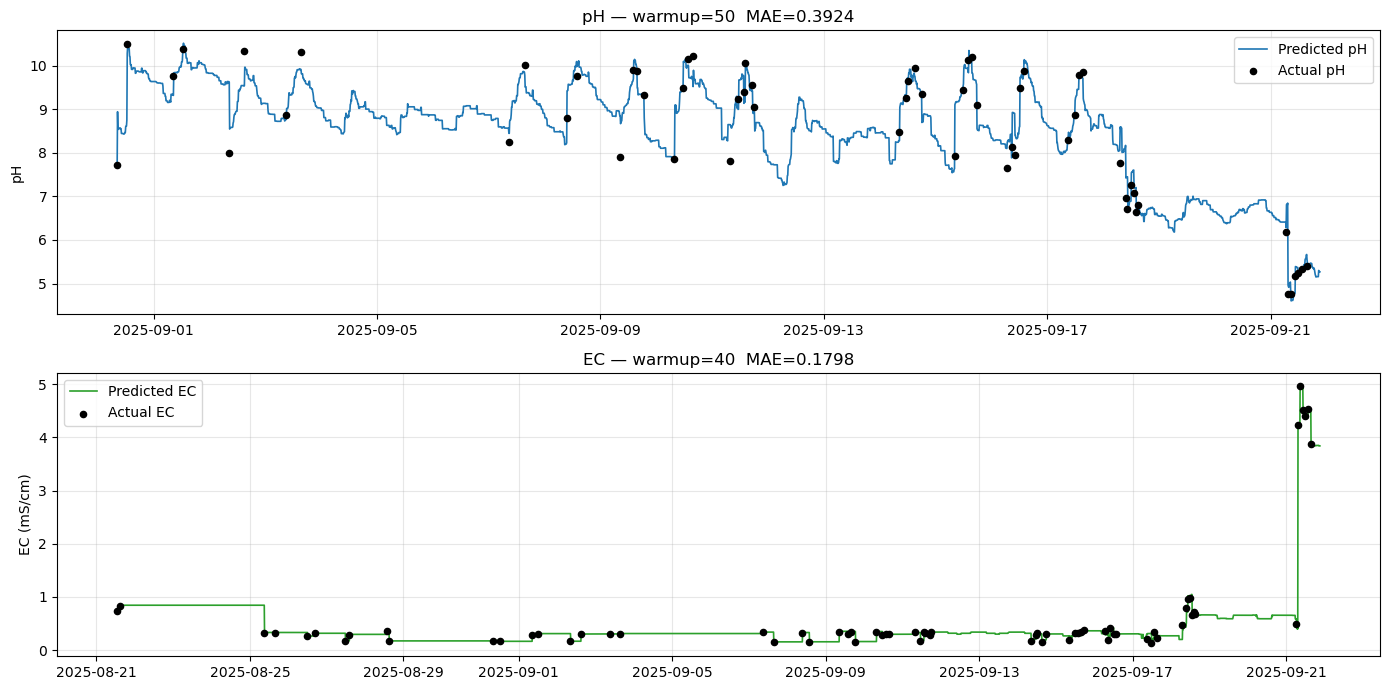

In [67]:
# ==========================================
# 7. Predicted vs Actual Time Series
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

axes[0].plot(res_ph.index, res_ph['ph_pred'], color='tab:blue', lw=1.2, label='Predicted pH')
axes[0].scatter(ev_ph.index, ev_ph['ph_true'], color='black', s=20, zorder=5, label='Actual pH')
axes[0].set_ylabel('pH')
axes[0].set_title(f'pH — warmup={WARMUP_PH}  MAE={m_ph["ph_mae"]:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(res_ec.index, res_ec['ec_pred'], color='tab:green', lw=1.2, label='Predicted EC')
axes[1].scatter(ev_ec.index, ev_ec['ec_true'], color='black', s=20, zorder=5, label='Actual EC')
axes[1].set_ylabel('EC (mS/cm)')
axes[1].set_title(f'EC — warmup={WARMUP_EC}  MAE={m_ec["ec_mae"]:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


pH Importance V4 (warmup=50): history importance = 0.279 (27.9%)
EC Importance V4 (warmup=40): history importance = 0.487 (48.7%)


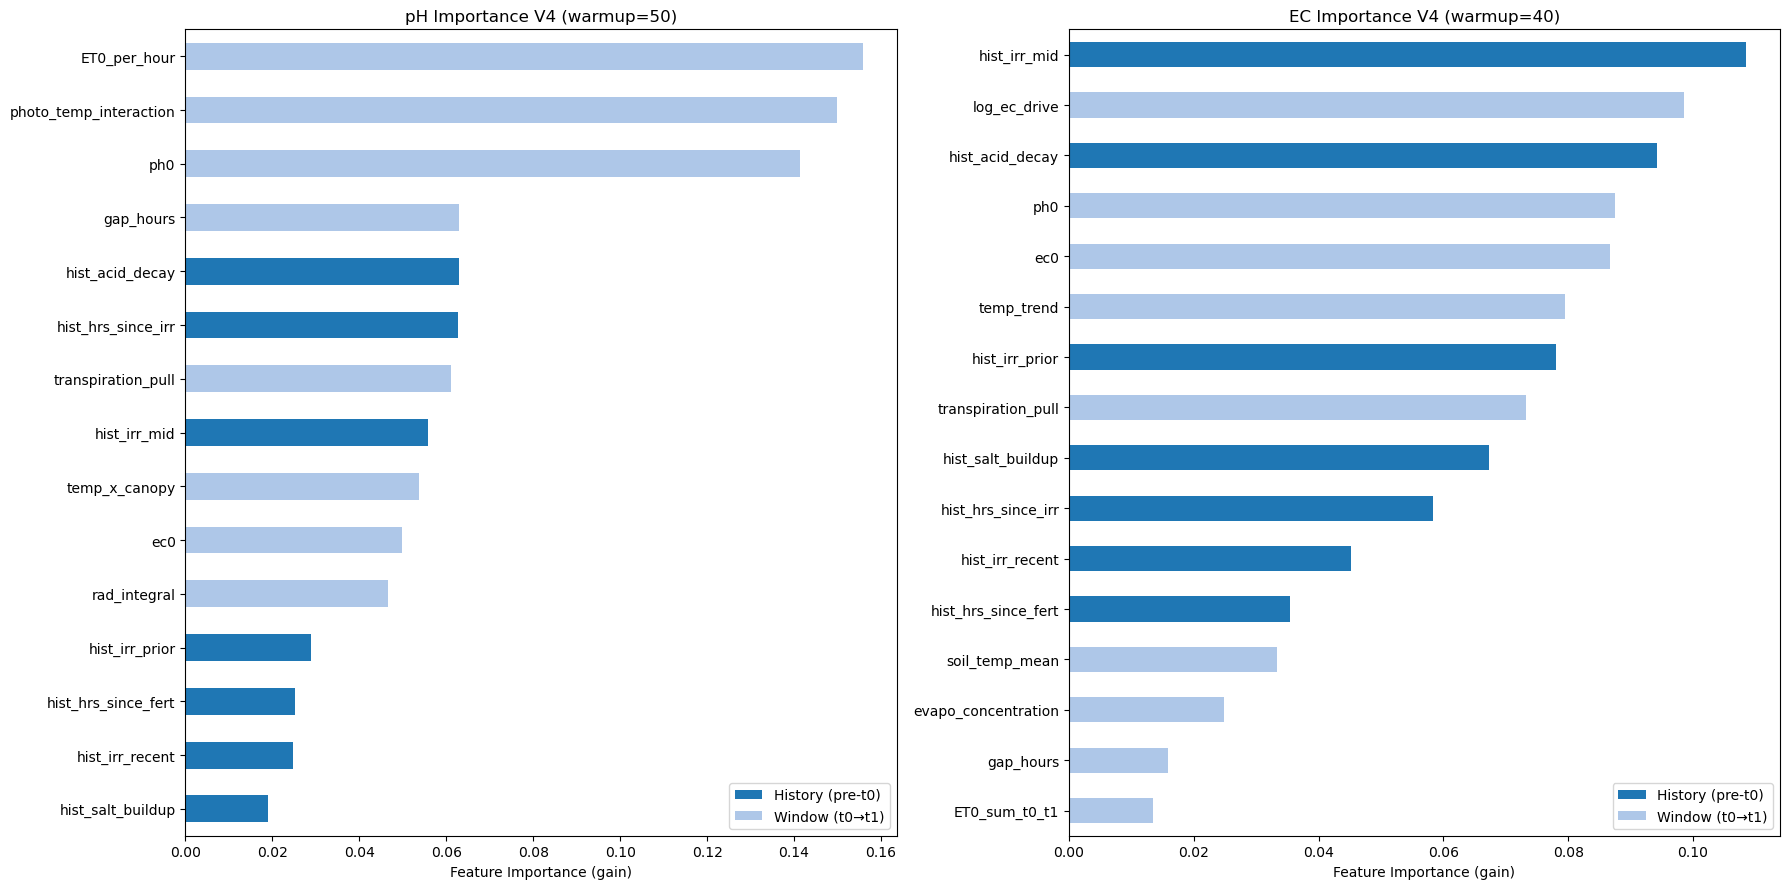

In [68]:
# ==========================================
# 8. Feature Importance — V4 (history vs window coloured)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

for ax, model, feat_cols, title in [
    (axes[0], ph_model, feature_cols_ph, f'pH Importance V4 (warmup={WARMUP_PH})'),
    (axes[1], ec_model, feature_cols_ec, f'EC Importance V4 (warmup={WARMUP_EC})'),
]:
    imp = pd.Series(model.feature_importances_, index=feat_cols).sort_values()
    colors = ['#1f77b4' if f in HIST_FEATS else '#aec7e8' for f in imp.index]
    imp.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(title)
    ax.set_xlabel('Feature Importance (gain)')

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#1f77b4', label='History (pre-t0)'),
        Patch(facecolor='#aec7e8', label='Window (t0→t1)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right')

    total_hist = sum(model.feature_importances_[i] for i, f in enumerate(feat_cols) if f in HIST_FEATS)
    print(f"{title}: history importance = {total_hist:.3f} ({total_hist*100:.1f}%)")

plt.tight_layout()
plt.show()


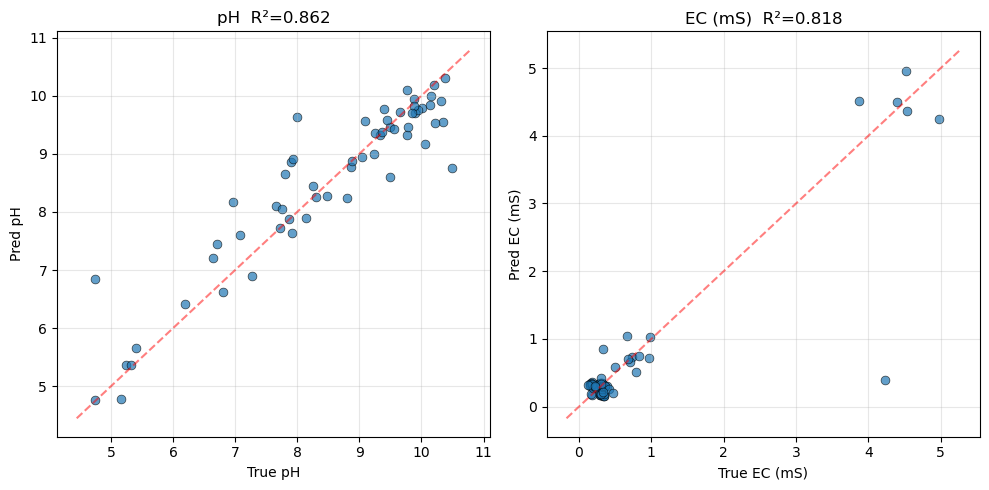

In [69]:
# ==========================================
# 9. Predicted vs Actual Scatter
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, ev, name, tc, pc in [
    (axes[0], ev_ph, 'pH',      'ph_true', 'ph_pred'),
    (axes[1], ev_ec, 'EC (mS)', 'ec_true', 'ec_pred'),
]:
    t = ev[tc].values
    p = ev[pc].values
    ax.scatter(t, p, alpha=0.7, s=40, edgecolors='k', lw=0.5)
    lims = [min(t.min(), p.min()) - 0.3, max(t.max(), p.max()) + 0.3]
    ax.plot(lims, lims, 'r--', alpha=0.5)
    ax.set_xlabel(f'True {name}')
    ax.set_ylabel(f'Pred {name}')
    ax.set_title(f'{name}  R²={r2_score(t, p):.3f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


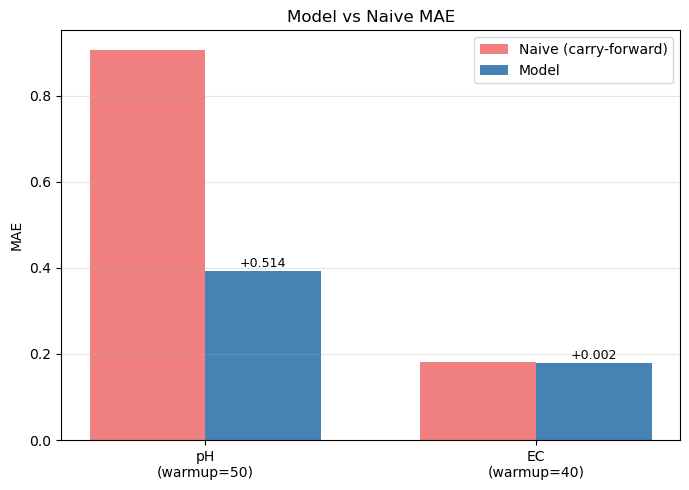

In [70]:
# ==========================================
# 10. Model vs Naive MAE — Summary Bar Chart
# ==========================================
targets   = ['pH', 'EC']
model_mae = [m_ph['ph_mae'],       m_ec['ec_mae']]
naive_mae = [m_ph['ph_mae_naive'], m_ec['ec_mae_naive']]
warmups_used = [WARMUP_PH, WARMUP_EC]

x = np.arange(len(targets))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, naive_mae, width, label='Naive (carry-forward)', color='lightcoral')
ax.bar(x + width/2, model_mae, width, label='Model',                 color='steelblue')

for i, (m, n, w) in enumerate(zip(model_mae, naive_mae, warmups_used)):
    gain = n - m
    ax.text(i + width/2, m + 0.002, f'+{gain:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f'pH\n(warmup={WARMUP_PH})', f'EC\n(warmup={WARMUP_EC})'])
ax.set_ylabel('MAE')
ax.set_title('Model vs Naive MAE')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


In [71]:
# ==========================================
# 11. Final Metrics Summary — V4
# ==========================================
summary = pd.DataFrame([
    {'Target': 'pH',  'Warmup': WARMUP_PH, 'MAE': m_ph['ph_mae'],  'RMSE': m_ph['ph_rmse'],
     'Naive MAE': m_ph['ph_mae_naive'], 'Gain': m_ph['ph_gain_mae'], 'R2': m_ph['ph_r2'],  'N test': m_ph['n_test']},
    {'Target': 'EC',  'Warmup': WARMUP_EC, 'MAE': m_ec['ec_mae'],  'RMSE': m_ec['ec_rmse'],
     'Naive MAE': m_ec['ec_mae_naive'], 'Gain': m_ec['ec_gain_mae'], 'R2': m_ec['ec_r2'],  'N test': m_ec['n_test']},
])
summary = summary.set_index('Target')
print(summary.to_string())


        Warmup       MAE      RMSE  Naive MAE      Gain        R2  N test
Target                                                                   
pH          50  0.392381  0.590228   0.906271  0.513890  0.861828      59
EC          40  0.179782  0.497787   0.181363  0.001581  0.817522      69
